In [1]:
import os
import random
import pandas as pd
import numpy as np

import sys

sys.path.insert(0, "..")

from unpast.run_unpast import unpast
from unpast.core.preprocessing import prepare_input_matrix
from unpast.misc.consensus import make_consensus_biclusters
from unpast.misc.eval import calc_ari_matching

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Run all four tests

In [2]:
# diseases and datasets
datasets_dict = {
    "breast_cancer":[
        "TCGA-BRCA",
        "METABRIC"
    ],
    "asthma":[
        "asthma_GSE4302",
        "asthma_GSE89809"
    ]
}
# diseases and subtypes
subtypes_dict = {
    "breast_cancer": ["Basal","Luminal","Her2","NE","Normal-like", "claudin-low","LumA","LumB"],
    "asthma":["Th2-high"]
}

results_dir = "../tmp_results/"
data_dir = "../unpast_benchmark_real_data/"
exprs_suffix = ".norm_log_exprs_z.tsv.gz"
annot_suffix = ".sample_annotation.tsv.gz"

# true biomarker table
sh_id = "1ikrwVFBfDcrQxyZKK_og9ajyqkL_or-zuLEFmhlSZ5Y"

analysis_seed = 42
n_runs = 5
biomarker_set = "curated"

# define unpast function with specific parameters
def run_unpast_func(exprs_file, seed=0, out_dir=""):
        return unpast(
            exprs_file,
            out_dir=out_dir,
            seed=seed,
            # specify parameters for all unpast runs
            clust_method="WGCNA",
            verbose=False,
)

In [3]:
def match_and_eval_biclusters(bics, annot_df, biomarkers_df, subtypes, biomarker_set="curated"):
    # prepare a dict with found clusters (from biclusters) 
    # convert sample clusters to a dict of sets {bic_id:{s1,s2,s3..}}
    pred_clusters = bics["samples"].to_dict()

    # prepare a dict with true clusters corresponding to subtypes 
    known_groups = {"all":{}}
    for subt in subtypes:
        known_groups["all"][str(subt)] = set(annot_df.loc[annot_df[subt]==1,:].index)

    # find signif. best matches for each subptypes with max. ARI
    all_samples = set(annot_df.index.values)
    wARIs, bm_stats = calc_ari_matching(
        bics,
        known_groups,  # dict={"classification1":{"group1":{"s1","s2",...},"group2":{...}, ...}}
        all_samples,  # set of all samples in input; needed for overlap p-value computations
        matching_measure= "ARI",  # must be "ARI" or "Jaccard"
        adjust_pvals = "B",  # ["B", "BH", False] # correction for multiple testing
        pval_cutoff  = 0.05,  # cutoff for p-values to select significant matches
        min_SNR = 0,
        min_n_genes = 2,
        min_n_samples = 2,
        verbose= False
        )

    for subt in subtypes:
        if not subt in biomarkers_df.index:
            # TBD - add row 'subt' with bm_id = NA
            pass
        true_bm_set = set(biomarkers_df.loc[subt,biomarker_set ].split(" "))
        bm_id = bm_stats.loc[subt,"bm_id"]
        # if best match for a subtype is found
        if not pd.isna(bm_id):
            #bm_stats.loc[subt,"bm_id"] = int(bm_id)
            genes_up = sorted(bics.loc[bm_id,"genes_up"].intersection(true_bm_set))
            genes_down = sorted(bics.loc[bm_id,"genes_down"].intersection(true_bm_set))

            if not bm_stats.loc[subt,"is_enriched"]:
                genes_up , genes_down = genes_down, genes_up 

            bm_stats.loc[subt,"up-reg"] = " ".join(genes_up)
            bm_stats.loc[subt,"down-reg"] = " ".join(genes_down)
            bm_stats.loc[subt,"n_biomarkers_in_bicluster"] = len(genes_up)+len(genes_down)
            bm_stats.loc[subt,"n_genes"] = bics.loc[bm_id,"n_genes"]
            bm_stats.loc[subt,"n_samples"] = bics.loc[bm_id,"n_samples"]
            bm_stats.loc[subt,"SNR"] = bics.loc[bm_id,"SNR"]

    cols = ['bm_id', 'ARI', 'adj_pval','is_enriched',  'up-reg',
           'down-reg', 'n_biomarkers_in_bicluster',"n_genes", "n_samples"]
    return bm_stats.loc[:,cols]

In [ ]:
best_matches = []
biclusters_dict = {}
for disease in sorted(datasets_dict.keys()):
    print(disease)
    
    # subtypes to take into account
    subtypes = subtypes_dict[disease]

    # read known biomarkers from a google-table
    url = (
        f"https://docs.google.com/spreadsheets/d/"
        f"{sh_id}/gviz/tq?tqx=out:csv&sheet={disease}"
    )
    biomarkers_df = pd.read_csv(url,index_col=0).loc[:,[biomarker_set]]
    
    # run unpast for each dataset for a disease
    # and evaluate the results 
    for ds_name in datasets_dict[disease]:
        print("\t",ds_name)
        
        exprs_file = data_dir+"/"+ds_name+exprs_suffix
        
        # seeds for n_runs
        random.seed(analysis_seed)
        seeds = []
        for i in range(n_runs):
            seeds.append(random.randint(0, 1000000))
        
        biclusters = []
        for seed in seeds:
            out_dir = f"{results_dir}/{ds_name}/run_seed_{seed}"
            bics = run_unpast_func(exprs_file,
                                    out_dir = out_dir,
                                    seed = seed)
            bics.index = ["seed=" + str(seed) + "_" + str(x) for x in bics.index.values]
            biclusters.append(bics)
            print("seed = %s\tn_biclusters: %s" % (seed, bics.shape[0]))
        
        
        # filter and z-score transform input matrix, limit z-scores to [-3,3]
        exprs_z = prepare_input_matrix(pd.read_csv(exprs_file, sep="\t", index_col=0),
                                       min_n_samples=5,
                                       ceiling=3)
        # consensus biclusters from n_runs
        cons_bics = make_consensus_biclusters(biclusters, 
                                         exprs_z, 
                                         seed=analysis_seed, 
                                         verbose=False, 
                                         plot=False)
        # add consensus to bicluster list and update seed list
        biclusters.append(cons_bics)
        seeds.append(analysis_seed)
        biclusters_dict = dict(zip(seeds, biclusters))
        
        # read true sample grouping(s) from annotation file
        annot_file = data_dir+ds_name+annot_suffix
        annot_df = pd.read_csv(annot_file,sep = "\t",index_col=0)
        annot_df = annot_df.fillna("NA")

        for i in range(len(seeds)):
            # find biclusters best matching subtypes and check biomarkers
            bm_stats = match_and_eval_biclusters(
                                                 biclusters[i],
                                                 annot_df,
                                                 biomarkers_df, 
                                                 subtypes, 
                                                 biomarker_set="curated"
                                                )
            bm_stats["dataset"] = ds_name
            bm_stats["disease"] = disease
            bm_stats["seed"] = seeds[i]

            best_matches.append(bm_stats)
    print("\n")
best_matches = pd.concat(best_matches)

In [16]:
best_matches.loc[best_matches["seed"]==analysis_seed,:]

,bm_id,ARI,adj_pval,is_enriched,up-reg,down-reg,n_biomarkers_in_bicluster,n_genes,n_samples,dataset,disease,seed
Th2-high,20,0.86507,0.000035,True,CLCA1 POSTN SERPINB2,,3.0,5.0,35,asthma_GSE4302,asthma,42
Th2-high,52,0.783191,0.000006,True,CLCA1 POSTN SERPINB2,,3.0,10.0,14,asthma_GSE89809,asthma,42
Basal,1,0.938534,0.000298,True,FOXC1,FOXA1 MLPH TFF3,4.0,403.0,195,TCGA-BRCA,breast_cancer,42
Luminal,4,0.714474,0.000492,False,AGR3 ESR1 GATA3,,3.0,213.0,263,TCGA-BRCA,breast_cancer,42
Her2,8,0.564921,0.000221,True,ERBB2 GRB7,,2.0,8.0,114,TCGA-BRCA,breast_cancer,42
NE,7,0.663889,0.000072,True,CHGA CHGB SEZ6 SYT4,,4.0,24.0,59,TCGA-BRCA,breast_cancer,42
Normal-like,155,0.069299,0.000059,True,,,0.0,5.0,254,TCGA-BRCA,breast_cancer,42
claudin-low,1,0.095434,0.000242,True,,,0.0,403.0,195,TCGA-BRCA,breast_cancer,42
LumA,120,0.467914,0.000695,True,,CDC45,1.0,5.0,446,TCGA-BRCA,breast_cancer,42
LumB,153,0.240626,0.00055,True,,,0.0,10.0,387,TCGA-BRCA,breast_cancer,42


### Plots 

In [7]:
df = best_matches.loc[:,:].copy()
df["subtype"] = df.index
df.index = np.arange(df.shape[0])

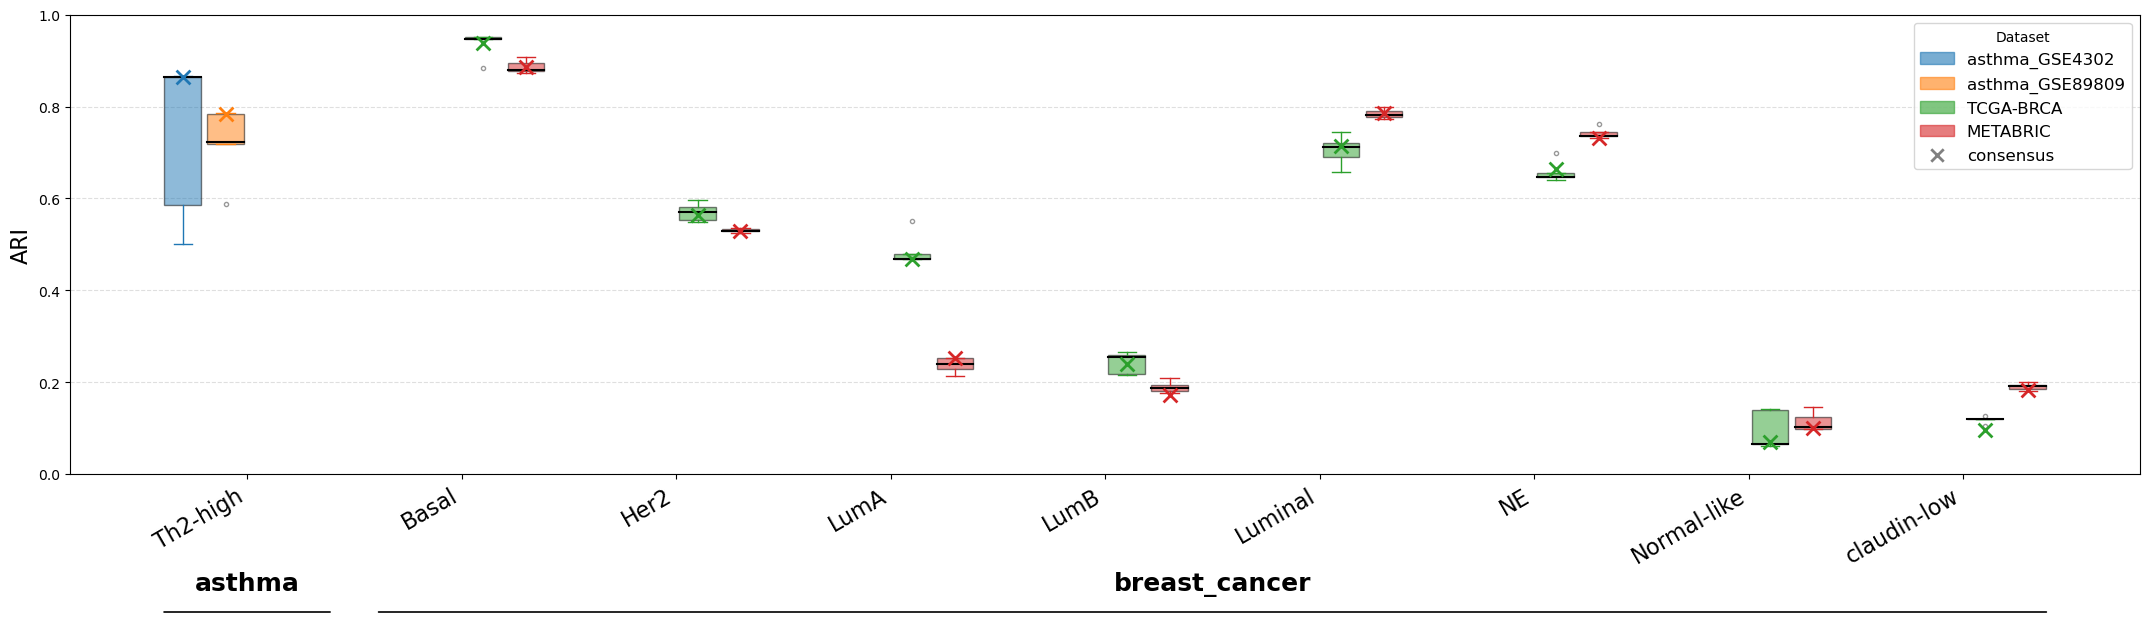

In [15]:
# --- Split data ---
df_multi = df[df["seed"] != analysis_seed].copy()
df_42 = df[df["seed"] == analysis_seed].copy()

# --- Setup ---
diseases = df["disease"].unique()
subtypes = df["subtype"].unique()
datasets = df["dataset"].unique()
palette = sns.color_palette("tab10", n_colors=len(datasets))
dataset_colors = dict(zip(datasets, palette))

# Build ordered groups: (disease, subtype) pairs
groups = df[["disease", "subtype"]].drop_duplicates().sort_values(["disease", "subtype"])
group_keys = list(zip(groups["disease"], groups["subtype"]))
x_pos = {g: i for i, g in enumerate(group_keys)}

n_datasets = len(datasets)
box_width = 0.8 / n_datasets  # subdivide each group slot per dataset

fig, ax = plt.subplots(figsize=(max(10, len(group_keys) * n_datasets * 0.6), 6))

for j, ds in enumerate(datasets):
    offset = (j - n_datasets / 2 + 0.5) * box_width

    for group in group_keys:
        disease, subtype = group
        x = x_pos[group] + offset

        # --- Boxplot (seed != analysis_seed) ---
        data = df_multi[
            (df_multi["disease"] == disease) &
            (df_multi["subtype"] == subtype) &
            (df_multi["dataset"] == ds)
        ]["ARI"].dropna()

        if len(data) > 0:
            ax.boxplot(
                data,
                positions=[x],
                widths=box_width * 0.85,
                patch_artist=True,
                boxprops=dict(facecolor=dataset_colors[ds], alpha=0.5),
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color=dataset_colors[ds]),
                capprops=dict(color=dataset_colors[ds]),
                flierprops=dict(marker="o", color=dataset_colors[ds], alpha=0.4, markersize=3),
                manage_ticks=False,
            )

        # --- consensus marker ---
        data42 = df_42[
            (df_42["disease"] == disease) &
            (df_42["subtype"] == subtype) &
            (df_42["dataset"] == ds)
        ]["ARI"].dropna()

        if len(data42) > 0:
            ax.scatter(
                x, data42.values[0],
                marker="x",
                color=dataset_colors[ds],
                s=100,
                linewidths=2,
                zorder=5,
            )

# --- X-axis labels: two-level (subtype on bottom, disease grouped above) ---
xtick_positions = [x_pos[g] for g in group_keys]
xtick_labels = [f"{subtype}" for disease, subtype in group_keys]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=30, ha="right", fontsize=16)

# Add disease group labels above x-axis via secondary tick annotations
disease_groups = {}
for disease, subtype in group_keys:
    disease_groups.setdefault(disease, []).append(x_pos[(disease, subtype)])

for disease, positions in disease_groups.items():
    center = np.mean(positions)
    ax.annotate(
        disease,
        xy=(center, 0), xycoords=("data", "axes fraction"),
        xytext=(0, -70), textcoords="offset points",
        ha="center", va="top", fontsize=18, fontweight="bold",
        annotation_clip=False,
    )
    # Draw a bracket line under the subtypes belonging to this disease
    left = min(positions) - 0.4
    right = max(positions) + 0.4
    y = -0.3
    ax.annotate("", xy=(right, y), xycoords=("data", "axes fraction"),
                xytext=(left, y), textcoords=("data", "axes fraction"),
                arrowprops=dict(arrowstyle="-", color="black", lw=1.2),
                annotation_clip=False)

ax.set_ylabel("ARI", fontsize=16)

ax.grid(axis="y", linestyle="--", alpha=0.4)

# --- Legend ---
color_patches = [mpatches.Patch(color=dataset_colors[ds], alpha=0.6, label=ds) for ds in datasets]
#box_patch = mpatches.Patch(facecolor="gray", alpha=0.5, label="Multi-seed (boxplot)")
x_marker = ax.scatter([], [], marker="x", color="gray", s=80, linewidths=2, label="consensus")

ax.legend(
    handles=color_patches + [ x_marker],
    loc="upper right",
    fontsize=12,
    title="Dataset",
)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
#plt.savefig("ari_combined.png", dpi=150, bbox_inches="tight")
plt.show()